# **Logistic Regression:** A Case Study on Clinical Data

Estimated time needed: 30-60 minutes

In this lab, you will work end-to-end through a logistic regression pipeline applied to a real-world multiclass classification problem. Logistic regression is far more than a simple binary classifier — its multinomial extension is the direct conceptual predecessor of the softmax layer in neural networks, and it remains a first-line model in industry for tabular data because it is fast, interpretable, and well-understood statistically.

By the end of this lab you will be able to reason about *why* each design decision is made, not just *how* to execute it in code. That reasoning skill — connecting algorithm choices to data properties and business requirements — is what separates a practitioner from a researcher.

**Problem context:** We use a real-world dataset containing detailed nutritional information for food items recommended to people managing diabetes. The task is to classify whether a diabetic patient should eat a given food item *More Often*, *Less Often*, or only *In Moderation* based on its nutritional profile.

In healthcare, a misclassification is not a neutral error — recommending a high-sugar food as "More Often" for a diabetic patient has real consequences. Throughout this lab, keep that cost asymmetry in mind as you evaluate model performance.

## Objectives


After completing this lab you will be able to:

* Explore and understand a real-world multiclass nutrition dataset
* Apply `MinMaxScaler` and `LabelEncoder` for feature and target preprocessing, understanding the *why* behind each choice
* Split data using stratified sampling to preserve class distributions across folds
* Train multinomial logistic regression models and understand the role of `solver`, `penalty`, and `multi_class` hyperparameters
* Compare L1 and L2 regularization strategies — understanding their sparsity and stability trade-offs
* Evaluate models using per-class precision, recall, and F1-score, not just aggregate accuracy
* Interpret trained models by analyzing feature coefficients in the context of the clinical domain
* Visualize normalized confusion matrices to identify systematic misclassification patterns

***


## Step 1: Environment Setup

Before any analysis, we establish a reproducible, version-controlled environment. In production ML systems, environment management is not optional — it is how teams guarantee that a model trained by one engineer can be reproduced, audited, or re-deployed by another months later.

In [1]:
# Optional: uncomment and run this cell only if running outside a managed environment (e.g., local Jupyter, Google Colab).
# Skills Network Labs pre-installs these packages, so this cell can be skipped there.
# !mamba install -qy pandas==1.3.3 numpy==1.21.2 ipywidgets==7.4.2 scipy==7.4.2 tqdm==4.62.3 matplotlib==3.5.0 seaborn==0.9.0
# Note: If your environment does not support mamba, use pip instead: !pip install ...

In [2]:
# The following versions need Python 3.11 or higher.
#!pip install pandas==3.0.2 numpy==2.4.4 ipywidgets==8.1.8 scipy==1.17.1 tqdm==4.67.3 matplotlib==3.10.9 seaborn==0.13.2 scikit-learn==1.8.0 --quiet

In [3]:
# --- Data manipulation ---
import pandas as pd
import numpy as np

# --- Preprocessing: scaling, encoding ---
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler

# --- Model selection: splitting and learning curve ---
from sklearn.model_selection import train_test_split, learning_curve

# --- Model: logistic regression ---
from sklearn.linear_model import LogisticRegression

# --- Evaluation metrics ---
from sklearn import metrics
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_fscore_support,
    precision_score, recall_score
)

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Print library versions for reproducibility records
import sklearn
print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__}")

pandas 2.3.3 | numpy 2.2.6 | scikit-learn 1.7.2


In [4]:
# Global random seed — passed to every stochastic operation in this notebook. Fixing the seed ensures that train/test splits, model weight initialization, and solver starting points are identical across runs, making results reproducible.
rs = 123

## Step 2: Exploratory Data Analysis (EDA) and Feature Engineering

No model should be trained before having a good understnding of the data. EDA is the discipline of asking structured questions about the dataset. In industry, skipping EDA is one of the most common sources of downstream model failures — distributions, missing values, and class imbalances that are ignored in EDA tend to resurface as bugs in production.

In this step we will:
- Inspect column types and ranges to verify data quality
- Examine the target variable's class distribution (critical for a classification task)
- Understand the clinical semantics of each feature before choosing a preprocessing strategy.

### 2.1 Load and Inspect the Dataset

We load the dataset into a Pandas DataFrame — the standard container for tabular data in Python ML workflows. After loading, we immediately inspect column data types. This is the first sanity check: every numeric feature should appear as `float64` or `int64`. Unexpected `object` types usually signal unparsed strings, mixed-type columns, or encoding artifacts that must be resolved before training.

In [5]:
# Load the dataset from its local path into a Pandas DataFrame
dataset_url = "data/food_items.csv"
food_df = pd.read_csv(dataset_url)

Check column data types — all feature columns should be numeric (`float64`), and the `class` column should be of type `object` (string labels):

In [6]:
# Inspect data types; all nutrient features should be numeric, the 'class' column string
food_df.dtypes

Calories               float64
Total Fat                int64
Saturated Fat          float64
Monounsaturated Fat    float64
Polyunsaturated Fat    float64
Trans Fat              float64
Cholesterol              int64
Sodium                 float64
Total Carbohydrate     float64
Dietary Fiber          float64
Sugars                 float64
Sugar Alcohol            int64
Protein                float64
Vitamin A                int64
Vitamin C                int64
Calcium                  int64
Iron                     int64
class                   object
dtype: object

Preview the first 10 rows to get a concrete sense of what a single food record looks like — the range of nutrient values and what the target label column contains:

In [7]:
# Preview the first 10 rows — examine nutrient ranges and confirm target label format
food_df.head(10)

,Calories,Total Fat,Saturated Fat,Monounsaturated Fat,Polyunsaturated Fat,Trans Fat,Cholesterol,Sodium,Total Carbohydrate,Dietary Fiber,Sugars,Sugar Alcohol,Protein,Vitamin A,Vitamin C,Calcium,Iron,class
0,149.0,0,0.0,0.0,0.0,0.0,0,9.0,9.8,0.0,0.0,0,1.3,0,0,0,0,'In Moderation'
1,123.0,0,0.0,0.0,0.0,0.0,0,5.0,6.6,0.0,0.0,0,0.8,0,0,0,0,'In Moderation'
2,150.0,0,0.0,0.0,0.0,0.0,0,4.0,11.4,0.0,0.0,0,1.3,0,0,0,0,'In Moderation'
3,110.0,0,0.0,0.0,0.0,0.0,0,6.0,7.0,0.0,0.0,0,0.8,0,0,0,0,'In Moderation'
4,143.0,0,0.0,0.0,0.0,0.0,0,7.0,13.1,0.0,0.0,0,1.0,0,0,0,0,'In Moderation'
5,110.0,0,0.0,0.0,0.0,0.0,0,6.0,7.0,0.0,0.0,0,0.8,0,0,0,0,'In Moderation'
6,142.0,0,0.0,0.0,0.0,0.0,0,12.0,10.6,0.0,0.0,0,1.2,0,0,0,0,'In Moderation'
7,102.0,0,0.0,0.0,0.0,0.0,0,13.0,5.0,0.0,0.0,0,0.7,0,0,0,0,'In Moderation'
8,145.0,0,0.0,0.0,0.0,0.0,0,17.0,11.0,0.0,0.0,0,1.2,0,0,0,0,'In Moderation'
9,171.0,0,0.0,0.0,0.0,0.0,0,8.0,13.7,0.0,0.0,0,2.5,0,0,0,0,'In Moderation'


Extract the names of all feature columns (everything except the last `class` column). Storing this list explicitly is a good practice — it lets us reference the features by name throughout the notebook for cleaner, self-documenting code:

In [8]:
# Select all columns except the last one (target 'class'); store as a list for later use
feature_cols = list(food_df.iloc[:, :-1].columns)
feature_cols

['Calories',
 'Total Fat',
 'Saturated Fat',
 'Monounsaturated Fat',
 'Polyunsaturated Fat',
 'Trans Fat',
 'Cholesterol',
 'Sodium',
 'Total Carbohydrate',
 'Dietary Fiber',
 'Sugars',
 'Sugar Alcohol',
 'Protein',
 'Vitamin A',
 'Vitamin C',
 'Calcium',
 'Iron']

### 2.2 Descriptive Statistics

Compute summary statistics for all feature columns. Pay attention to the range of each nutrient — large differences in scale (e.g., Calories ranging into the hundreds vs. a micronutrient in single digits) will cause gradient-based solvers to converge poorly and will make coefficient magnitudes incomparable. This observation directly motivates the scaling step that follows:

In [9]:
# Summary statistics: count, mean, std, min, quartiles, max for each nutrient feature
food_df.iloc[:, :-1].describe()

,Calories,Total Fat,Saturated Fat,Monounsaturated Fat,Polyunsaturated Fat,Trans Fat,Cholesterol,Sodium,Total Carbohydrate,Dietary Fiber,Sugars,Sugar Alcohol,Protein,Vitamin A,Vitamin C,Calcium,Iron
count,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000
mean,133.861086,4.475264,1.450617,0.338069,0.254660,0.047459,8.857692,241.867142,18.232020,1.602971,6.645234,0.117949,4.661333,6.287632,6.741855,5.175264,5.235671
std,94.227650,5.386340,2.410318,1.345852,2.230586,0.321402,20.976530,272.284363,14.786316,3.363879,8.328465,1.121529,5.611143,18.374191,23.785100,8.779637,9.119459
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,120.000000,3.000000,0.500000,0.000000,0.000000,0.000000,0.000000,135.000000,17.000000,1.000000,3.000000,0.000000,3.000000,0.000000,0.000000,2.000000,2.000000
75%,180.000000,7.000000,2.000000,0.000000,0.000000,0.000000,10.000000,370.000000,27.000000,2.000000,11.000000,0.000000,7.000000,6.000000,2.000000,6.000000,8.000000
max,2210.000000,43.000000,22.000000,40.000000,235.000000,11.000000,450.000000,2431.000000,270.000000,305.000000,115.000000,31.000000,70.000000,622.000000,1000.000000,110.000000,170.000000


The dataset contains 17 nutrient features (Calories, Total Fat, Protein, Sugars, etc.), all expressed as continuous numeric values. Because these variables are measured on completely different scales, we will apply **Min-Max scaling** to compress each feature into the range [0, 1]. This has two important consequences:

1. **Solver convergence:** L-BFGS and SAGA (the solvers used in this notebook) converge significantly faster on features with similar scales.

2. **Coefficient comparability:** After scaling, the magnitude of a logistic regression coefficient directly reflects a feature's relative influence on the predicted class — features with large absolute coefficients matter more. Without scaling, a feature measured in hundreds would dominate simply due to its unit, not its true predictive power.

### 2.3 Target Variable: Class Distribution

Before training any classifier, we must understand the class balance in the target variable. A model that naively predicts the majority class at all times can achieve high accuracy while providing zero useful discrimination. We inspect both the relative proportions and the absolute counts:

In [10]:
# Relative frequencies of each class — reveals imbalance at a glance
food_df.iloc[:, -1:].value_counts(normalize=True)

class          
'In Moderation'    0.501433
'Less Often'       0.423906
'More Often'       0.074661
Name: proportion, dtype: float64

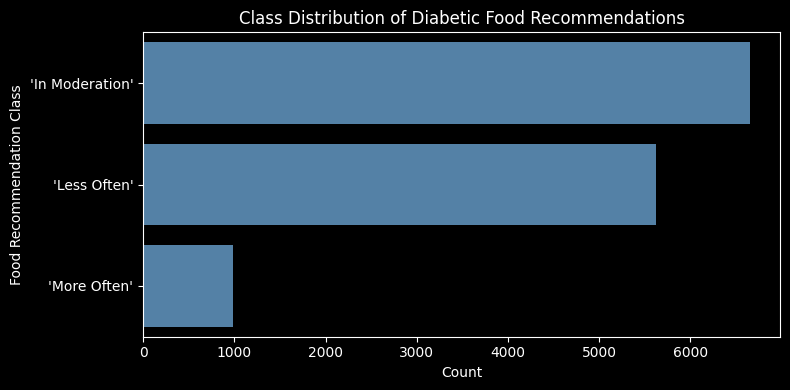

In [11]:
# Bar chart of absolute class counts — visualizes the imbalance across the three categories
with plt.style.context('dark_background'):
    fig, ax = plt.subplots(figsize=(8, 4))
    counts = food_df.iloc[:, -1:].value_counts().reset_index()
    counts.columns = ['class', 'count']
    sns.barplot(data=counts, x='count', y='class', color='steelblue', ax=ax)
    ax.set_xlabel("Count")
    ax.set_ylabel("Food Recommendation Class")
    ax.set_title("Class Distribution of Diabetic Food Recommendations")
    plt.tight_layout()
    plt.show()


The bar chart reveals three classes — `In Moderation`, `Less Often`, and `More Often` — that are **not equally represented**. Most food items fall into the `In Moderation` or `Less Often` categories, while the `More Often` class is significantly underrepresented.

**Why this matters:** A classifier trained on imbalanced data tends to optimize for the majority class, producing inflated aggregate accuracy while failing on the rare (but often clinically important) minority class. In this dataset, being unable to identify `More Often` foods means patients miss out on genuinely beneficial dietary choices. We will track per-class performance metrics (precision, recall, F1) throughout this lab rather than relying on accuracy alone.

> **Industry note:** In production healthcare systems, class imbalance is addressed through techniques such as oversampling (`SMOTE`), class weighting (`class_weight='balanced'`), or threshold calibration. We will cover these approaches in later modules.

### 2.4 Multinomial Logistic Regression

Because we have **three classes**, we need a multinomial (also called *softmax*) logistic regression rather than a standard binary one. In multinomial logistic regression, the model learns a separate set of coefficients for each class. At prediction time, it computes a raw score (logit) for each class and passes all scores through the **softmax** function to produce a valid probability distribution:

$$P(y = k \mid \mathbf{x}) = \frac{e^{\mathbf{w}_k^\top \mathbf{x}}}{\sum_{j=1}^{K} e^{\mathbf{w}_j^\top \mathbf{x}}}$$

where $K = 3$ is the number of classes. The predicted class is whichever class has the highest probability.

This is conceptually identical to the final classification layer of a neural network — logistic regression *is* a single-layer neural network with a softmax output.

**Multinomial vs. One-vs-Rest (OvR):** These are two fundamentally different strategies for extending binary logistic regression to $K > 2$ classes.

| Strategy | How it works | When to prefer it |
|---|---|---|
| **Multinomial (Softmax)** | One joint model; probabilities sum to 1 across all classes | Classes are mutually exclusive; you want calibrated probabilities |
| **One-vs-Rest (OvR)** | $K$ independent binary classifiers; each separates class $k$ vs. all others | When classes are not mutually exclusive, or when computational cost matters |

In this lab we use `multi_class='multinomial'` because a food item belongs to exactly one recommendation category — the classes are mutually exclusive, and the softmax probabilities are directly interpretable as a recommendation confidence.

## Step 3: Feature Engineering and Preprocessing

Feature engineering is the bridge between raw data and a trainable model. Even when features are already numeric (as in this dataset), we must apply preprocessing to satisfy the assumptions and convergence requirements of the learning algorithm. Two transformations are needed here:

1. **Feature scaling (`MinMaxScaler`)** — Normalizes all nutrient values to [0, 1] so that every feature competes on equal footing during optimization and coefficients can be meaningfully compared.
2. **Label encoding (`LabelEncoder`)** — Converts the string class labels (`"In Moderation"`, `"Less Often"`, `"More Often"`) into integer codes (0, 1, 2) that scikit-learn's model expects as the target array `y`.

### 3.1 Separate Features and Target

First, we separate the dataset into `X_raw` (all feature columns) and `y_raw` (the target column). This is a standard convention that keeps input features and labels clearly distinct throughout the pipeline.

Pay attention to the slice notation used in pandas `.iloc[]`: The syntax `[rows, columns]` takes two arguments separated by a comma. A colon `:` alone means *all* items in that dimension. The notation `:-1` means *all except the last* item.


In [12]:
# Select all rows (first : in square bracket) and all columns except the last one (:-1)
X_raw = food_df.iloc[:, :-1]
# Select all rows of only the last column (-1:), the target label
y_raw = food_df.iloc[:, -1:]

### 3.2 Scale the Feature Matrix with MinMaxScaler

All feature columns are already numeric, so no one-hot encoding is needed. We apply `MinMaxScaler`, which transforms each feature $x_i$ as:

$$x_i^{\prime} = \frac{x_i - x_{\min}}{x_{\max} - x_{\min}}$$

This maps every feature to the interval [0, 1] while preserving the original shape of the distribution. 

**Important:** We call `fit_transform` on the full feature matrix here because we are treating this as a preliminary EDA step. In the train/test split that follows, the correct production practice is to `fit` the scaler on training data only and `transform` both train and test sets — to prevent data leakage.

In [13]:
# Instantiate MinMaxScaler — learns per-feature min and max during fit()
scaler = MinMaxScaler()

# fit_transform: learns the per-feature min/max from X_raw, then scales the matrix.
# Result X is a NumPy array with all values in [0, 1].
X = scaler.fit_transform(X_raw)

# Verify the scaling output — every value should fall in [0.0, 1.0]

print(f"Feature value range after scaling: [{X.min():.4f}, {X.max():.4f}]")

Feature value range after scaling: [0.0000, 1.0000]


### 3.3 Encode the Target Variable with LabelEncoder

Scikit-learn's classifiers expect the target `y` to be a 1-D array of integers. `LabelEncoder` assigns a consistent integer code to each unique string label. The mapping is alphabetical by default: `"In Moderation" → 0`, `"Less Often" → 1`, `"More Often" → 2`.

**Why not `OneHotEncoder` for the target?** `OneHotEncoder` would expand the target into a binary matrix, which is appropriate for some frameworks (e.g., Keras) but unnecessary for scikit-learn, which handles multi-class targets internally as integer codes.

In [14]:
# Instantiate LabelEncoder — will learn the string-to-integer mapping during fit()
label_encoder = LabelEncoder()

In [15]:
# ravel() flattens the single-column DataFrame into a 1-D NumPy array, as required by LabelEncoder
y = label_encoder.fit_transform(y_raw.values.ravel())

Confirm the encoding mapping and verify the sample counts per class. The encoded array `y` will contain only integers `{0, 1, 2}` corresponding to:
- `0` → `In Moderation`
- `1` → `Less Often`
- `2` → `More Often`

In [16]:
# Returns unique integer codes and their frequencies — confirms encoding and reflects the class imbalance seen earlier
np.unique(y, return_counts=True)

(array([0, 1, 2]), array([6649, 5621,  990]))

## Step 4: Train and Evaluate Logistic Regression Models

With preprocessed features and labels in hand, we are ready to train our models. We will compare two regularization strategies — **L2 (Ridge)** and **L1 (Lasso)** — to understand how the choice of penalty affects model performance, coefficient sparsity, and generalization.

Regularization adds a penalty term to the cross-entropy loss to prevent the model from overfitting by learning excessively large coefficients. The two most common forms are:

| Regularization | Penalty term | Effect on coefficients | Common use case |
|---|---|---|---|
| **L2 (Ridge)** | $\lambda \sum w_i^2$ | Shrinks all coefficients smoothly; none reach exactly zero | When all features are expected to contribute |
| **L1 (Lasso)** | $\lambda \sum w_i$ | Can drive some coefficients to exactly zero; performs implicit feature selection | When the feature space has irrelevant or redundant features |

In this nutrition dataset, where several nutrient variables are likely correlated (e.g., Total Fat and Saturated Fat), L1 regularization may offer a meaningful advantage.

### 4.1 Train/Test Split with Stratification

We split the data into training (80%) and testing (20%) sets. The `stratify=y` argument ensures that each split preserves the same class proportions as the original dataset. This is critical for imbalanced datasets: without stratification, the small `More Often` class could end up almost entirely in one split by random chance, leading to misleading evaluation results.

**Industry practice:** In real ML pipelines, you typically see a three-way split (train / validation / test) or nested cross-validation. The validation set is used for hyperparameter tuning, and the held-out test set is only touched once for final reporting. Using the test set during tuning inflates performance estimates — a form of data leakage.

In [17]:
# Stratified split: preserves the class ratio from y in both train and test sets.
# test_size=0.2 → 20% of data held out for final evaluation; random_state ensures reproducibility.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=rs
)

Confirm the dimensions of the resulting splits — the number of training samples and features should match our expectations:

In [18]:
print(f"Training set  — X: {X_train.shape}, y: {y_train.shape}")

Training set  — X: (10608, 17), y: (10608,)


In [19]:
print(f"Test set      — X: {X_test.shape},  y: {y_test.shape}")

Test set      — X: (2652, 17),  y: (2652,)


The splits are ready. We now move to model definition and training. We will first train an **L2-regularized multinomial logistic regression** as our baseline.

### 4.2 Define the L2-Regularized Model

We define a `LogisticRegression` model with the following hyperparameters. Understanding the role of each is essential before tuning them:

In [20]:
# L2 (Ridge) penalty: adds sum-of-squared-weights to the loss.
# Shrinks all coefficients toward zero without eliminating any.
# Good default when you expect most features to contribute.
penalty = 'l2'

# Multinomial: fits a joint softmax model over all K classes simultaneously. Alternative 'ovr' would train K independent binary classifiers.
multi_class = 'multinomial'

# L-BFGS: quasi-Newton optimizer; efficient for small-to-medium datasets with L2 penalty. Supports multinomial loss natively.
solver = 'lbfgs'

# Maximum number of optimization iterations before declaring convergence failure. Increase if a ConvergenceWarning is raised.
max_iter = 1000

In [21]:
# Instantiate the L2-regularized multinomial logistic regression model
l2_model = LogisticRegression(
    random_state=rs,
    penalty=penalty,
    multi_class=multi_class,
    solver=solver,
    max_iter=max_iter
)

### 4.3 Train the L2 Model

Calling `fit()` runs the optimization loop: the solver minimizes the regularized cross-entropy loss over the training data, iteratively updating the coefficient matrix until convergence (or `max_iter` is reached). The result is a learned coefficient matrix of shape `(n_classes, n_features)` — one row of coefficients per class:

In [22]:
# Train the L2 model on the training split — returns the fitted model object
l2_model.fit(X_train, y_train)

/Users/souvikmandal/Documents/S01_Learning/IBM_Machine-Learning-Professional-Certificate/ML_Venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,123
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


In [23]:
# Generate hard class predictions on the test set (argmax of the softmax probabilities internally)
l2_preds = l2_model.predict(X_test)

### 4.4 Evaluation Utility

We define a reusable `evaluate_metrics()` function that computes four standard classification metrics. We report **per-class** values for precision, recall, and F1, rather than a single aggregated number — this is the correct approach when class distributions are imbalanced.

| Metric | What it measures | Formula |
|---|---|---|
| **Accuracy** | Overall fraction correct | $\frac{TP + TN}{\text{all samples}}$ |
| **Precision** (per class) | Of all predicted positives, how many are truly positive | $\frac{TP}{TP + FP}$ |
| **Recall** (per class) | Of all actual positives, how many were correctly retrieved | $\frac{TP}{TP + FN}$ |
| **F1-score** (per class) | Harmonic mean of precision and recall | $2 \cdot \frac{P \cdot R}{P + R}$ |

In [24]:
def evaluate_metrics(yt, yp):
    """
    Compute classification evaluation metrics.

    Parameters
    ----------
    yt : array-like of shape (n_samples,)
        Ground-truth class labels.
    yp : array-like of shape (n_samples,)
        Predicted class labels.

    Returns
    -------
    dict with keys:
        'accuracy' : float
        'recall'   : np.ndarray, shape (n_classes,) — per-class recall
        'precision': np.ndarray, shape (n_classes,) — per-class precision
        'f1score'  : np.ndarray, shape (n_classes,) — per-class F1
    """
    results = {}
    results['accuracy'] = accuracy_score(yt, yp)
    # precision_recall_fscore_support returns per-class arrays (no averaging)
    precision, recall, f_beta, _ = precision_recall_fscore_support(yt, yp)
    results['recall'] = recall
    results['precision'] = precision
    results['f1score'] = f_beta
    return results

In [25]:
# Evaluate L2 model: per-class precision, recall, F1, plus overall accuracy
l2_eval_metrics = pd.DataFrame(evaluate_metrics(y_test, l2_preds))
l2_eval_metrics

,accuracy,recall,precision,f1score
0,0.774887,0.873684,0.730358,0.795618
1,0.774887,0.732206,0.835533,0.780465
2,0.774887,0.353535,0.921053,0.510949


**L2 model evaluation — key observations:**

- Overall accuracy is reasonable (~77%), but accuracy alone is a misleading headline metric when classes are imbalanced.
- Look at the per-class recall values: recall for **class 2 (`More Often`)** is notably lower than for the other two classes. The model struggles to identify foods that diabetic patients *should* eat more of.
- This is a direct consequence of the class imbalance noted in the EDA step: with fewer training examples for `More Often`, the model has less evidence to learn that boundary.

**Clinical implication:** A low recall for `More Often` means the model frequently misclassifies genuinely beneficial foods as something else — a false negative with practical consequences for patient diet quality.

We will next train an L1-regularized model to see if implicit feature selection improves performance on this difficult class.

## Step 5: L1-Regularized Model — Feature Selection via Sparsity

We now train a second logistic regression model using **L1 (Lasso) regularization**. The key difference from L2 is that the L1 penalty can drive individual coefficients to *exactly zero*, effectively removing those features from the model. This is called **automatic feature selection** — the optimizer decides which features are uninformative and drops them.

In a nutrition dataset with potentially correlated features (e.g., Total Fat, Saturated Fat, and Trans Fat are all measures of dietary fat), L1 regularization may improve generalization by eliminating redundant predictors and reducing overfitting. This is analogous to what analysts do manually when they drop highly correlated columns — but L1 does it in a principled, data-driven way during training.

In [26]:
# L1 (Lasso) penalty: adds sum-of-absolute-weights to the loss.
# Key difference from L2: L1 can reduce coefficients to exactly zero (sparse solution).
# This implicitly selects a subset of the most important features.
penalty = 'l1'

# Still using multinomial (softmax) formulation for 3-class prediction
multi_class = 'multinomial'

# SAGA (Stochastic Average Gradient Augmented) solver:
# Required for L1 + multinomial combination; handles sparse solutions efficiently.
# Note: lbfgs does NOT support L1 penalty — solver selection is not arbitrary.
solver = 'saga'

# Keep max iterations the same for a fair comparison with the L2 model
max_iter = 1000

Instantiate the L1 model with the same architecture and random seed for a fair head-to-head comparison:

In [27]:
# Define the L1-regularized multinomial logistic regression model
l1_model = LogisticRegression(
    random_state=rs,
    penalty=penalty,
    multi_class=multi_class,
    solver=solver,
    max_iter=max_iter
)

Train the L1 model on the same training split used for the L2 baseline:

In [28]:
# Fit the L1 model on training data — SAGA optimizer runs its stochastic update iterations
l1_model.fit(X_train, y_train)

/Users/souvikmandal/Documents/S01_Learning/IBM_Machine-Learning-Professional-Certificate/ML_Venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,123
,solver,'saga'
,max_iter,1000
,multi_class,'multinomial'


Generate hard class predictions on the test set:

In [29]:
# Predict class labels for the test set
l1_preds = l1_model.predict(X_test)

### 5.1 Inspecting Class Probabilities

Beyond hard predictions, `predict_proba()` returns the full softmax probability distribution over all classes for each sample. This is often more informative than the predicted label alone — a probability of 0.96 vs. 0.52 for the winning class conveys very different levels of confidence. In clinical decision support systems, low-confidence predictions are often flagged for human review rather than acted on automatically:

In [30]:
# Softmax probability distribution for the first test sample across all 3 classes
# Values sum to 1.0; the argmax gives the predicted class
odd_ratios = l1_model.predict_proba(X_test[:1, :])[0]
odd_ratios

array([3.55065558e-02, 9.64491964e-01, 1.47991419e-06])

The three values are the predicted probabilities for classes 0, 1, and 2 respectively — they sum to 1.0. The class with the highest probability is the model's prediction (class 1, `Less Often`, at ~0.96). The `predict()` method is simply a shorthand for `argmax(predict_proba())` at threshold 0.5:

In [31]:
# Confirm: predict() returns the argmax of predict_proba() — should match class index of max probability above
l1_model.predict(X_test[:1, :])[0]

np.int64(1)

### 5.2 Evaluate the L1 Model

In [32]:
# Evaluate L1 model — compare per-class metrics with the L2 baseline above
l1_eval_metrics = pd.DataFrame(evaluate_metrics(y_test, l1_preds))
l1_eval_metrics

,accuracy,recall,precision,f1score
0,0.809201,0.854887,0.788488,0.820346
1,0.809201,0.743772,0.835165,0.786824
2,0.809201,0.873737,0.827751,0.850123


### Step 5 Summary — L1 vs. L2: What Changed and Why

The L1 model shows **improved performance** over the L2 baseline. The likely reason is that L1's sparsity-inducing penalty zeros out coefficients for correlated or noisy features (e.g., redundant fat-related nutrients), producing a simpler model that generalizes better on the test set.

**L1 vs. L2 — practical decision guide for industry:**

| Scenario | Prefer |
|---|---|
| Many features, only a few are truly predictive | **L1** — for automatic feature selection and model compression |
| All features are expected to contribute (e.g., pixel intensities) | **L2** — stable shrinkage without elimination |
| Features are highly correlated | **L1** (or Elastic-Net) — L2 distributes weight across correlated groups rather than selecting one |
| Need a deployable model with fewer active features | **L1** — zero coefficients reduce scoring computation and improve interpretability |
| Coefficient stability matters more than sparsity | **L2** — L1 solutions can change sharply with small data perturbations |

In production ML teams, the regularization penalty and its strength (controlled by `C = 1/λ`) are treated as hyperparameters tuned via cross-validation using `LogisticRegressionCV` or a grid search pipeline.

## Step 6: Confusion Matrix — Understanding Where the Model Fails

Aggregate metrics like accuracy and F1 tell you *how well* a model performs overall, but they do not tell you *which specific errors* the model is making. The confusion matrix fills this gap by showing the full breakdown of predicted vs. actual classes.

For a 3-class problem, the confusion matrix is a $3 \times 3$ grid where:
- **Diagonal cells** (top-left to bottom-right) = correct predictions
- **Off-diagonal cells** = errors, with the position indicating which class was predicted instead of which

We use the **row-normalized** version (`normalize='true'`), which converts each row to a probability distribution. This makes **recall per class** readable directly from the diagonal: cell $(i, i)$ is the fraction of class-$i$ samples that were correctly classified.

Compute the normalized confusion matrix for the L1 model predictions:

In [33]:
# normalize='true' divides each row by its true class count → diagonal = per-class recall
cf = confusion_matrix(y_test, l1_preds, normalize='true')

Visualize with `ConfusionMatrixDisplay` — a scikit-learn utility that wraps the matrix in a labeled heatmap, making systematic misclassification patterns immediately visible:

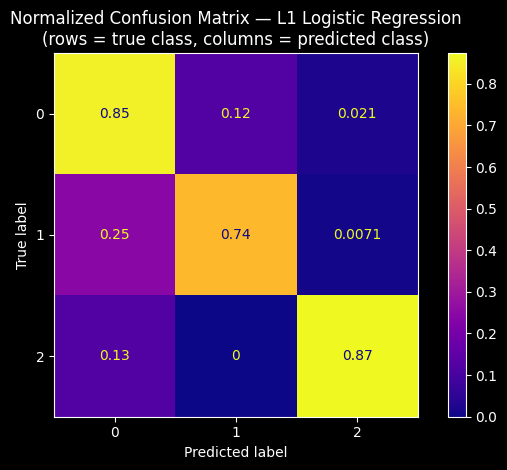

In [34]:
# ConfusionMatrixDisplay wraps the normalized matrix with axis labels from the model's class list
plt.style.use('dark_background')
disp = ConfusionMatrixDisplay(confusion_matrix=cf, display_labels=l1_model.classes_)
disp.plot(cmap='plasma')
plt.title("Normalized Confusion Matrix — L1 Logistic Regression\n(rows = true class, columns = predicted class)")
plt.tight_layout()
plt.show()

### Step 6 Summary — Confusion Matrix Insights

Read the matrix row by row (each row is one true class):
- **Diagonal** — the fraction of that class correctly predicted (= class recall)
- **Off-diagonal** — misclassification patterns (e.g., many `More Often` samples predicted as `In Moderation` would show a large value in row 2, column 0)

**Industry use of confusion matrices:**
Confusion matrices are a standard deliverable in ML model review meetings. Teams use them to:
1. **Prioritize error reduction** — focus engineering effort on the most costly off-diagonal cells
2. **Justify threshold changes** — adjusting the decision threshold shifts the recall/precision trade-off in a predictable direction
3. **Monitor model drift** — comparing confusion matrices across time periods reveals if the error pattern is changing as data distribution shifts
4. **Communicate with stakeholders** — a confusion matrix is more intuitive to a clinical audience than an F1 score

---

## Step 7: Model Interpretation via Feature Coefficients

One of logistic regression's most important advantages over black-box models (e.g., random forests, neural networks) is its **interpretability**. The coefficient for feature $j$ in class $k$ tells us how a one-unit increase in $x_j$ (after scaling) changes the log-odds of predicting class $k$, holding all other features constant.

Formally, the log-odds of class $k$ given feature vector $\mathbf{x}$ is:

$$\log\frac{P(y=k \mid \mathbf{x})}{P(y=0 \mid \mathbf{x})} = \mathbf{w}_k^\top \mathbf{x} + b_k$$

Key reading rules:
- A **large positive coefficient** for class $k$ means that feature strongly pushes predictions toward class $k$
- A **large negative coefficient** means that feature strongly pushes predictions *away* from class $k$
- A **zero coefficient** (from L1 sparsity) means that feature was deemed uninformative for class $k$

**This directly connects to domain knowledge:** if saturated fat has a large positive coefficient for the `Less Often` class, the model has learned something that nutritionists already know. When model coefficients contradict domain knowledge, it is a signal worth investigating — it may indicate data issues, confounders, or a model that has overfit.

Inspect the raw coefficient matrix from the trained L1 model. The shape is `(n_classes, n_features)` — three rows (one per class) and 17 columns (one per nutrient). Notice that many values are exactly 0.0 — that is L1 sparsity in action:

In [35]:
# coef_ shape: (n_classes, n_features) = (3, 17)
# Row index 0 = class 0 (In Moderation), 1 = class 1 (Less Often), 2 = class 2 (More Often)
# Zeros indicate features that L1 regularization drove to exactly zero (removed from that class boundary)
pd.DataFrame(l1_model.coef_).transpose()

,0,1,2
0,10.226061,0.000000,-111.431018
1,0.000000,4.202235,-29.141045
2,0.000000,24.664847,0.000000
3,5.282116,0.000000,0.000000
4,0.000000,0.000000,0.000000
5,-3.705606,0.000000,0.000000
6,0.000000,4.942775,0.000000
7,0.911924,0.000000,-1.596429
8,0.000000,1.322515,-41.343789
9,22.662750,-6.798347,0.000000


The raw coefficient array is hard to read. We use three helper functions below to extract, sort, and visualize the nonzero coefficients for each class as a horizontal bar chart. This makes the relative magnitude and direction of each feature's influence immediately legible:

In [36]:
def get_feature_coefs(regression_model, label_index, columns):
    """
    Extract non-trivial feature coefficients for a given class.

    Coefficients with |value| < 0.01 are treated as effectively zero and excluded
    (a display threshold, not a model change — these may have been driven to near-zero by L1).

    Parameters
    ----------
    regression_model : fitted LogisticRegression
    label_index      : int — row index in coef_ corresponding to the target class
    columns          : list of str — feature names matching the column order of coef_

    Returns
    -------
    dict sorted ascending by coefficient value: {feature_name: coefficient}
    """
    coef_dict = {}
    for coef, feat in zip(regression_model.coef_[label_index, :], columns):
        if abs(coef) >= 0.01:  # Filter near-zero coefficients for cleaner visualization
            coef_dict[feat] = coef
    # Sort by value (most negative → most positive) for a clean horizontal bar chart
    coef_dict = {k: v for k, v in sorted(coef_dict.items(), key=lambda item: item[1])}
    return coef_dict


def get_bar_colors(values):
    """Assign red (r) to negative coefficients and green (g) to positive ones."""
    return ['r' if val <= 0 else 'g' for val in values]


def visualize_coefs(coef_dict, title='Feature Coefficients'):
    """
    Render a horizontal bar chart of feature coefficients.

    Red bars = features pushing prediction *away* from the target class.
    Green bars = features pushing prediction *toward* the target class.
    """
    features = list(coef_dict.keys())
    values = list(coef_dict.values())
    y_pos = np.arange(len(features))
    color_vals = get_bar_colors(values)

    plt.rcdefaults()
    fig, ax = plt.subplots(figsize=(8, max(4, len(features) * 0.4)))
    ax.barh(y_pos, values, align='center', color=color_vals)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    ax.invert_yaxis()  # Highest positive coefficient at top
    ax.set_xlabel('Coefficient Value (after Min-Max scaling)')
    ax.set_title(title)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')  # Zero reference line
    plt.tight_layout()
    plt.show()

### 7.1 Coefficients for Class 1 — `Less Often`

These coefficients show which nutrients most strongly predict that a food should be eaten *less often* by diabetic patients. A positive coefficient means that higher amounts of that nutrient push the model toward predicting `Less Often`:

In [37]:
# Extract coefficients for class index 1 = 'Less Often'
coef_dict = get_feature_coefs(l1_model, 1, feature_cols)

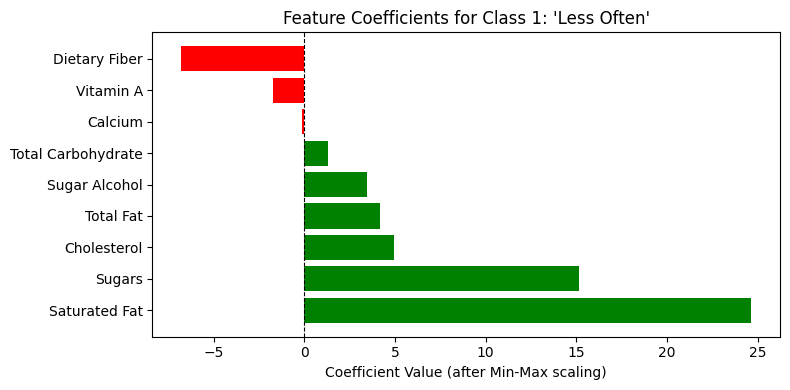

In [38]:
# Horizontal bar chart: green = nutrient increases 'Less Often' probability, red = decreases it
visualize_coefs(coef_dict, title="Feature Coefficients for Class 1: 'Less Often'")

The coefficients align well with clinical nutrition knowledge: **Saturated Fat, Sugars, Cholesterol, and Total Fat** carry large positive coefficients, meaning foods high in these nutrients are pushed toward the `Less Often` class. This is domain-consistent — these are the same nutrients flagged by dietary guidelines as risks for diabetic complications.

Notice also that some coefficients are exactly 0.0 and do not appear in the chart — L1 regularization determined those nutrients were not informative for distinguishing this class boundary.

### 7.2 Coefficients for Class 2 — `More Often`

Now examine the same picture from the other side: which nutrients predict that a food should be eaten *more often* by diabetic patients. Here we expect nutrients like Fiber, Protein, and micronutrients to carry positive coefficients, while energy-dense nutrients should be negative:

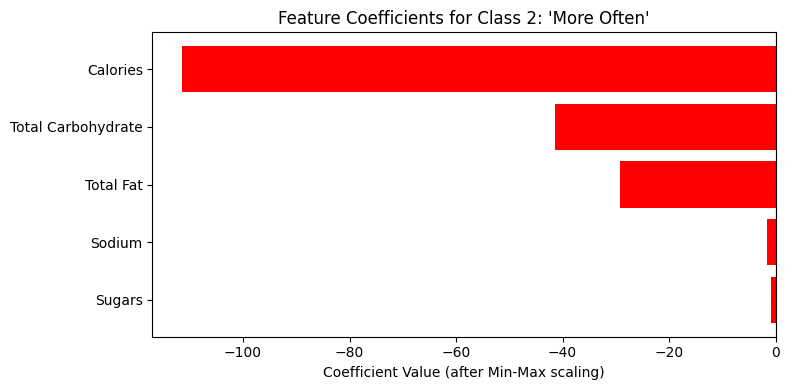

In [39]:
# Extract and visualize coefficients for class index 2 = 'More Often'
coef_dict = get_feature_coefs(l1_model, 2, feature_cols)
visualize_coefs(coef_dict, title="Feature Coefficients for Class 2: 'More Often'")

Conversely, high Calories, Total Carbohydrates, and Total Fat are strongly *negatively* associated with the `More Often` class — the model has learned that energy-dense foods are unlikely to be in the "eat freely" category for diabetic patients. This is consistent with clinical guidance.

**Step 7 Summary — Why coefficient analysis matters in industry:**

Model interpretability is not merely academic — it is a regulatory and trust requirement in high-stakes domains:
- **Healthcare:** Explainability is required under FDA guidance for AI/ML-based software as a medical device (SaMD). Clinicians need to understand *why* the model recommended a class.
- **Finance:** GDPR Article 22 and the EU AI Act require explanations for automated decisions affecting individuals.
- **Operations:** Coefficient analysis helps catch "Clever Hans" models — models that achieve high accuracy for spurious reasons (e.g., a label that happens to correlate with a data artifact).

Logistic regression's transparency is one of its most valuable industrial properties. Before deploying a more opaque model, teams often ask: "Can logistic regression solve this problem well enough?" — because a model that is good enough *and* interpretable is often preferable to a marginally better black box.

## Step 8: Coding Exercise — Elastic-Net Regularization

You have now walked through the full pipeline for L2 and L1 logistic regression. Your task is to independently apply the same workflow for a **third regularization strategy: Elastic-Net**.

**What is Elastic-Net?**
Elastic-Net combines both L1 and L2 penalties:

$$\mathcal{L}_{\text{EN}} = \text{Cross-Entropy} + \lambda \left[ \alpha \sum |w_i| + (1-\alpha) \sum w_i^2 \right]$$

where $\alpha$ (the `l1_ratio` parameter in scikit-learn) controls the blend:
- `l1_ratio = 1.0` → pure L1 (same as Lasso)
- `l1_ratio = 0.0` → pure L2 (same as Ridge)
- `0 < l1_ratio < 1` → Elastic-Net: partial sparsity + smooth shrinkage

Elastic-Net is particularly useful when features are grouped and correlated — it tends to select whole groups rather than arbitrarily picking one representative (as pure L1 does).

**Your goal:** Determine whether Elastic-Net can match or improve upon the L1 performance achieved in Step 5.

Follow the same four-step workflow as the L1/L2 models: **Define → Train → Evaluate → Interpret**. Use the hints provided in each section if you get stuck. After completing all steps, reflect on the comparison: does Elastic-Net offer any practical advantage over pure L1 on this dataset?

### 8.1 Define an Elastic-Net Logistic Regression Model

Set the hyperparameters below. Recall from the L1 model that scikit-learn **only supports the `saga` solver** for Elastic-Net. You must also set `l1_ratio` to a value strictly between 0 and 1 to activate the Elastic-Net blend (any boundary value collapses it to pure L1 or L2):

In [ ]:
# sklearn only support saga solver for elastic-net penality
# and you need to set another l1_ratio to be within 0 < l1_ratio <1, in order to actually use elastic-net

# --- 8.1 Define ---
penalty     = 'elasticnet'
multi_class = 'multinomial'
solver      = 'saga'       # Only solver supporting elasticnet + multinomial
max_iter    = 1000
l1_ratio    = 0.5          # Equal blend of L1 and L2; try values between 0.1 and 0.9

### 8.2 Train the Elastic-Net Model on Training Data

In [ ]:
en_model = LogisticRegression(
    random_state=rs,
    penalty=penalty,
    multi_class=multi_class,
    solver=solver,
    max_iter=max_iter,
    l1_ratio=l1_ratio
)

# --- 8.2 Train ---
en_model.fit(X_train, y_train)

/Users/souvikmandal/Documents/S01_Learning/IBM_Machine-Learning-Professional-Certificate/ML_Venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'elasticnet'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,123
,solver,'saga'
,max_iter,1000
,multi_class,'multinomial'


### 8.3 Evaluate the Model — Accuracy, Precision, Recall, F1-Score

Use the `evaluate_metrics()` utility defined earlier. Compare the per-class F1 scores with those from the L1 and L2 models. Pay particular attention to class 2 (`More Often`) — the hardest class to predict:

In [ ]:
# --- 8.3 Evaluate ---
en_preds = en_model.predict(X_test)
pd.DataFrame(evaluate_metrics(y_test, en_preds))

,accuracy,recall,precision,f1score
0,0.790724,0.866917,0.753103,0.806012
1,0.790724,0.732206,0.837233,0.781206
2,0.790724,0.611111,0.876812,0.720238


### 8.4 Plot the Normalized Confusion Matrix

Use `confusion_matrix(normalize='true')` and `ConfusionMatrixDisplay` as in Step 6. Does the Elastic-Net model make the same types of errors as L1, or does it shift the error pattern?

In [ ]:
# --- 8.4 Confusion matrix ---
cf_en = confusion_matrix(y_test, en_preds, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cf_en, display_labels=en_model.classes_)
disp.plot(cmap='Blues')
plt.title("Normalized Confusion Matrix — Elastic-Net Logistic Regression")
plt.tight_layout()
plt.show()

### 8.5 Interpret the Model via Feature Coefficients

Use `get_feature_coefs()` and `visualize_coefs()` to plot coefficients for the `Less Often` class (class index 1). How does the sparsity pattern compare to the L1 model? Are more or fewer features zeroed out?

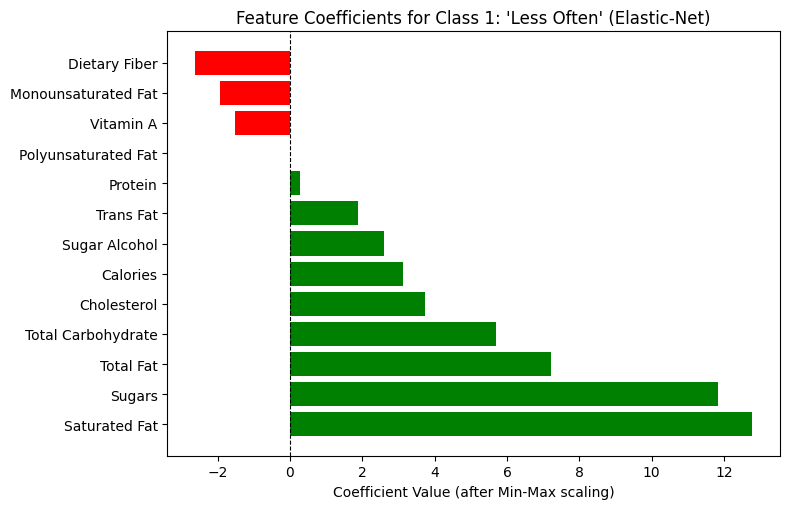

In [50]:
# --- 8.5 Coefficients for 'Less Often' ---
coef_dict = get_feature_coefs(en_model, 1, feature_cols)
visualize_coefs(coef_dict, title="Feature Coefficients for Class 1: 'Less Often' (Elastic-Net)")

**Discussion:** Elastic-Net typically produces a solution with fewer zero coefficients than pure L1, but more than L2. It is particularly well-suited when you believe groups of correlated features should all remain in the model (rather than having L1 arbitrarily pick one representative per group). Experiment with different `l1_ratio` values (0.1, 0.5, 0.9) and observe how performance and sparsity change.

## Conclusion and Next Steps

In this lab, you built and compared three logistic regression models on a real-world clinical nutrition classification task. Here is a summary of the conceptual arc:

| Step | What we did | Key insight |
|---|---|---|
| EDA | Explored the dataset structure and class balance | Class imbalance is a fundamental problem requiring per-class metrics |
| Feature Engineering | Scaled features, encoded labels | Scaling enables fair coefficient comparison; LabelEncoder prepares the target |
| Data Split | Stratified train/test split | Stratification preserves class ratios; prevents imbalance in evaluation |
| L2 Model | Trained Ridge-regularized logistic regression | Smooth shrinkage; all features retained; reasonable baseline |
| L1 Model | Trained Lasso-regularized logistic regression | Sparse coefficients; implicit feature selection; improved generalization |
| Confusion Matrix | Visualized misclassification patterns | Exposes which class boundaries are hardest; essential for clinical review |
| Coefficients | Interpreted model via feature weights | Domain-consistent results; L1 zeroed uninformative nutrient features |
| Exercise | Elastic-Net regularization | L1+L2 blend; useful for correlated feature groups |

**What comes next in the course:**

The remaining modules will introduce classification models with fundamentally different inductive biases and structural assumptions — decision trees, SVMs, k-Nearest Neighbors, and ensemble methods. As you encounter each, ask yourself:

1. What assumptions does this model make about the data-generating process?
2. How does its decision boundary differ from the linear boundary of logistic regression?
3. In what real-world scenarios would it outperform logistic regression — and when would it not be worth the added complexity?

Logistic regression's linear decision boundary is both its limitation and its strength. It is the right starting point for any new classification problem: fast to train, easy to explain, and a solid baseline against which all more complex models must justify themselves.

## Authors


Primary structure of this notebook is made by [Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML241ENSkillsNetwork31576874-2021-01-01), 2021 IBM Corporation (Copyright ©).

Content added and modernized by [Souvik Mandal](https://www.linkedin.com/in/souvik-mandal-phd/), 2026.
